In [1]:
import pandas as pd

In [2]:
nav = pd.read_csv('../data/processed/nav_history_clean.csv')

In [3]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head()  

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
var_cvar = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    var_95 = returns.quantile(0.05)

    cvar_95 = returns[returns <= var_95].mean()

    var_cvar.append([
        code,
        var_95,
        cvar_95
    ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'var_95', 'cvar_95']
)

var_cvar_df.head()

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
var_cvar_df.to_csv("../reports/var_cvar_report.csv", index=False)


In [7]:
nav['amfi_code'].unique()[:5]

array([100016, 100025, 100033, 101206, 101207])

In [8]:
top_5_funds = nav['amfi_code'].value_counts().nlargest(5).index

In [10]:
import numpy as np

rolling_sharpe = pd.DataFrame()

for fund in top_5_funds:

    temp = nav[nav['amfi_code'] == fund].copy()

    temp['rolling_sharpe'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_sharpe = pd.concat([
        rolling_sharpe,
        temp
    ])

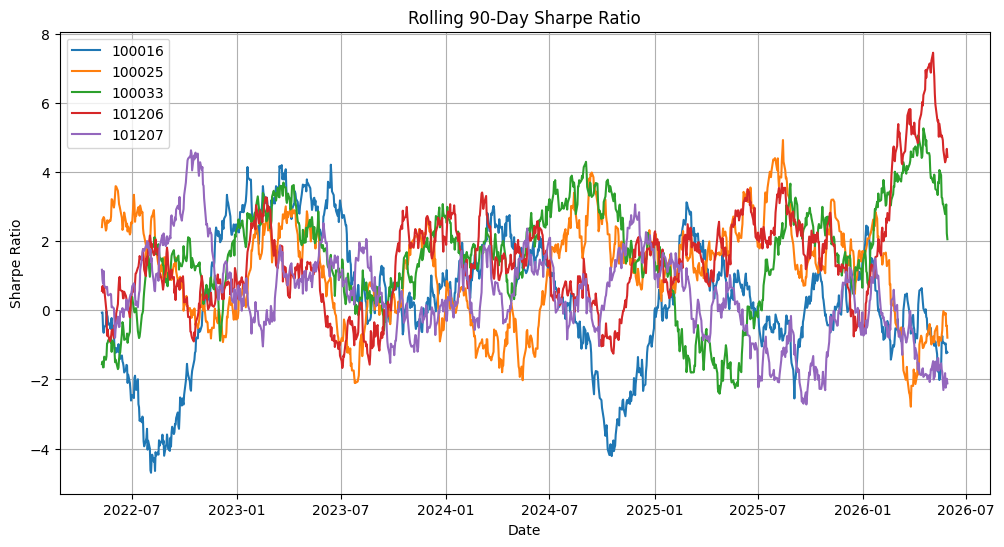

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top_5_funds:

    temp = rolling_sharpe[
        rolling_sharpe['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [13]:
transactions = pd.read_csv('../data/processed/investor_transactions_clean.csv')  

In [14]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

first_year = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .dt.year
    .reset_index()
)

first_year.columns = [
    'investor_id',
    'cohort_year'
]

first_year.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [15]:
transactions = transactions.merge(
    first_year,
    on='investor_id',
    how='left'
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [16]:
cohort_summary = (
    transactions
    .groupby('cohort_year')
    .agg(
        investors=('investor_id','nunique'),
        avg_investment=('amount_inr','mean'),
        total_investment=('amount_inr','sum')
    )
    .reset_index()
)

cohort_summary

,cohort_year,investors,avg_investment,total_investment
0,2024,4803,107422.541832,3491125187
1,2025,197,109158.577061,30455243


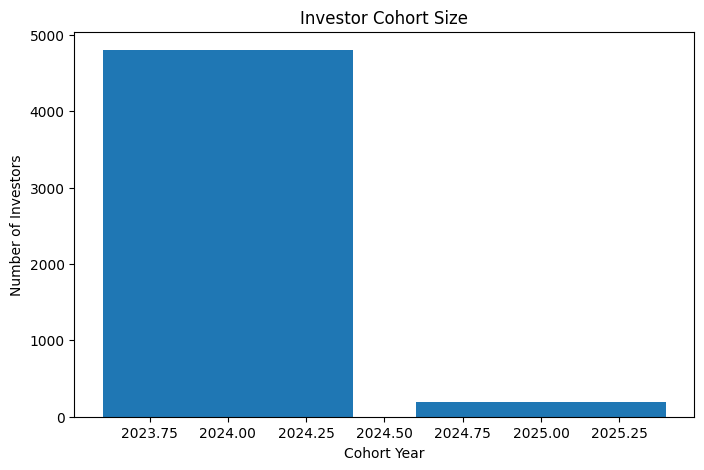

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    cohort_summary['cohort_year'],
    cohort_summary['investors']
)

plt.title("Investor Cohort Size")
plt.xlabel("Cohort Year")
plt.ylabel("Number of Investors")

plt.show()

In [18]:
transactions = transactions.sort_values(
    ['investor_id', 'transaction_date']
)

In [19]:
transactions['days_gap'] = (
    transactions
    .groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,days_gap
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0


In [20]:
sip_continuity = (
    transactions
    .groupby('investor_id')
    .agg(
        avg_gap_days=('days_gap','mean'),
        total_transactions=('transaction_date','count')
    )
    .reset_index()
)

sip_continuity.head()

,investor_id,avg_gap_days,total_transactions
0,INV000001,38.000,3
1,INV000002,82.800,6
2,INV000003,238.000,2
3,INV000004,53.375,9
4,INV000005,52.000,8


In [21]:
sip_continuity['risk_flag'] = (
    sip_continuity['avg_gap_days']
    .apply(
        lambda x: 'At Risk'
        if x > 35
        else 'Regular'
    )
)

In [22]:
sip_continuity['risk_flag'].value_counts()

risk_flag
At Risk    4305
Regular     695
Name: count, dtype: int64

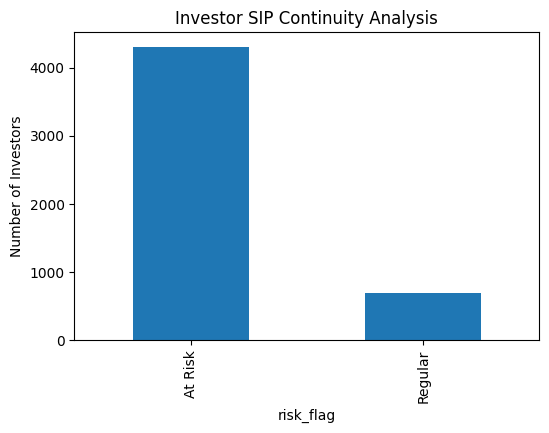

In [23]:
risk_counts = (
    sip_continuity['risk_flag']
    .value_counts()
)

plt.figure(figsize=(6,4))

risk_counts.plot(
    kind='bar'
)

plt.title(
    'Investor SIP Continuity Analysis'
)

plt.ylabel(
    'Number of Investors'
)

plt.show()

In [24]:
sip_continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)